In [ ]:
# =======================================
# FAKE NEWS DETECTION - EVALUATION NOTEBOOK
# =======================================

# Import libraries
import numpy as np
import pandas as pd
import pickle
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, roc_curve, auc
)
from tensorflow.keras.models import load_model

print("Libraries loaded successfully.")


: 

In [21]:
# =======================================
# Load model, tokenizer & dataset
# =======================================

MODEL_PATH = 'models/model_best.h5'
TOKENIZER_PATH = 'data/processed/tokenizer.pkl'
DATA_PATH = 'data/processed/cleaned_dataset.csv'

# Load model and tokenizer
model = load_model(MODEL_PATH)
with open(TOKENIZER_PATH, 'rb') as f:
    tokenizer = pickle.load(f)

# Load dataset
df = pd.read_csv(DATA_PATH).dropna(subset=['clean_join', 'label']).reset_index(drop=True)
print(f"Loaded dataset with {len(df)} samples.")
df.head()


Loaded dataset with 44919 samples.


,title,text,subject,label,clean_join
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,FAKE,donald trump sends embarrassing new year s eve...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,FAKE,drunk bragging trump staffer started russian c...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,FAKE,sheriff david clarke becomes internet joke thr...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,FAKE,trump obsessed he even obama s name coded his ...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,FAKE,pope francis called donald trump his christmas...


In [22]:
# =======================================
# Data preprocessing
# =======================================

# Convert labels to 0 (fake) and 1 (real)
labels = df['label'].astype(str).str.lower().map({'fake': 0, 'false': 0, 'real': 1, 'true': 1})

# Tokenize and pad
seqs = tokenizer.texts_to_sequences(df['clean_join'])
max_len = 500
X = tf.keras.preprocessing.sequence.pad_sequences(seqs, maxlen=max_len, padding='post')
y_true = np.array(labels)

print("Tokenization complete.")
print(f"Input shape: {X.shape}")


Tokenization complete.
Input shape: (44919, 500)


In [23]:
# =======================================
# Model prediction
# =======================================

y_pred_prob = model.predict(X, verbose=1)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("Predictions complete.")


1404/1404 ━━━━━━━━━━━━━━━━━━━━ 91s 64ms/step
Predictions complete.


In [24]:
# =======================================
# Evaluation metrics
# =======================================

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))

# Save metrics as CSV (optional)
results = pd.DataFrame([{
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
}])
results.to_csv('models/evaluation_metrics.csv', index=False)
print("\nMetrics saved to models/evaluation_metrics.csv")


Accuracy:  0.9478
Precision: 0.9986
Recall:    0.8918
F1-score:  0.9422

Classification Report:
              precision    recall  f1-score   support

        Fake       0.91      1.00      0.95     23502
        Real       1.00      0.89      0.94     21417

    accuracy                           0.95     44919
   macro avg       0.95      0.95      0.95     44919
weighted avg       0.95      0.95      0.95     44919


Metrics saved to models/evaluation_metrics.csv


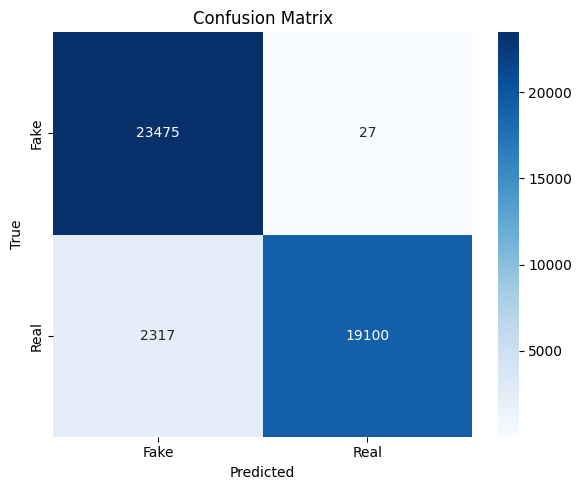

Confusion matrix saved as models/confusion_matrix.png


In [ ]:
# =======================================
# Confusion Matrix
# =======================================

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('models/confusion_matrix.png')
plt.show()
print("Confusion matrix saved as models/confusion_matrix.png")


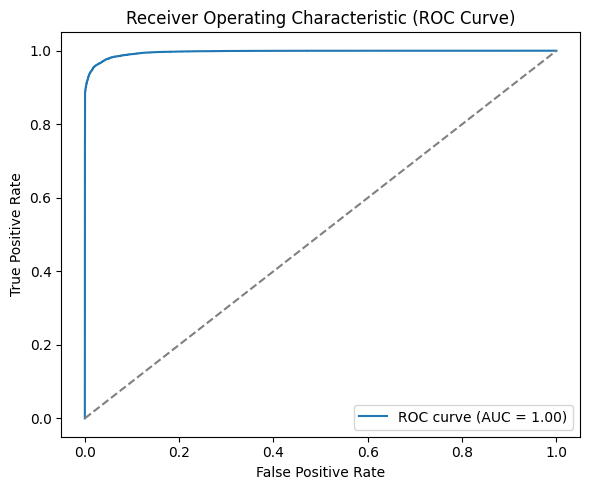

ROC curve saved as models/roc_curve.png


In [26]:
# =======================================
# ROC Curve
# =======================================

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC Curve)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('models/roc_curve.png')
plt.show()

print("ROC curve saved as models/roc_curve.png")


In [27]:
# ================================
# Summary
# ================================
print("""
Evaluation complete!

Files generated:
 - models/evaluation_metrics.csv
 - models/confusion_matrix.png
 - models/roc_curve.png
""")



Evaluation complete!

Files generated:
 - models/evaluation_metrics.csv
 - models/confusion_matrix.png
 - models/roc_curve.png

